## Importing required libraries

In [100]:
import numpy as np
import pandas as pd


import re
import nltk
nltk.download('punkt')
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report



import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shrut\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Loading amazon Dataset

In [101]:
df = pd.read_csv(r"C:\files\AU jupyter\Amazon_recomendation_System\amazon_products_sales_data_uncleaned.csv")   # change file name
df.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


## checking dimension of dataset

In [102]:
df.shape

(42675, 16)

## Getting information about dataset using info() methodm

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   title                     42675 non-null  object
 1   rating                    41651 non-null  object
 2   number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   current/discounted_price  30926 non-null  object
 5   price_on_variant          42675 non-null  object
 6   listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

## Droping sustainability_badges column

In [104]:
if 'sustainability_badges' in df.columns:
    df = df.drop(columns=['sustainability_badges'])


## creating a function with function name clean_numbers() to clean numerical columns

In [105]:
def clean_numbers(x):
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    return float(x) if x != '' else 0






## cleaning numerical column using clean_numbers() function

In [106]:
# Apply cleaning
df['rating'] = df['rating'].apply(clean_numbers)
df['number_of_reviews'] = df['number_of_reviews'].apply(clean_numbers)
df['listed_price'] = df['listed_price'].apply(clean_numbers)

## Analysing column values

In [107]:
df['is_best_seller'].value_counts() 

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

In [108]:
df['buy_box_availability'].value_counts()

buy_box_availability
Add to cart    28022
Name: count, dtype: int64

In [109]:
df['is_sponsored'].value_counts()

is_sponsored
Organic      35664
Sponsored     7011
Name: count, dtype: int64

## converting columns to numeric column

In [110]:
# Convert categorical columns
df['is_best_seller'] = df['is_best_seller'].map({'Best Seller':1, 'No':0})
df['is_sponsored'] = df['is_sponsored'].map({'Sponsored':1, 'Organic':0})

## filling null value with zero

In [111]:
df = df.fillna(0)


## creating score column

In [112]:
df['score'] = df['rating'] * np.log1p(df['number_of_reviews'])


## EDA

## Price Distribution

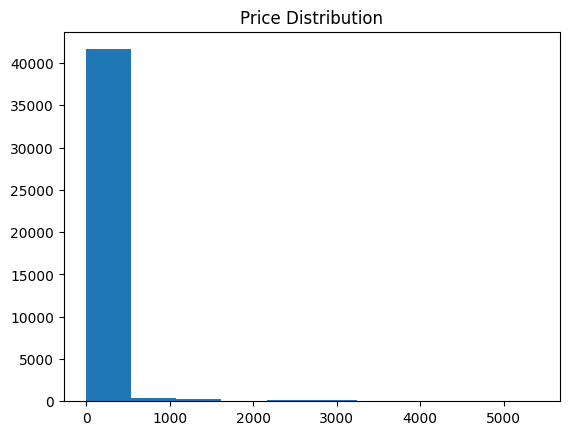

In [113]:
plt.hist(df['listed_price'])
plt.title("Price Distribution")
plt.show()

## Rating Distribution

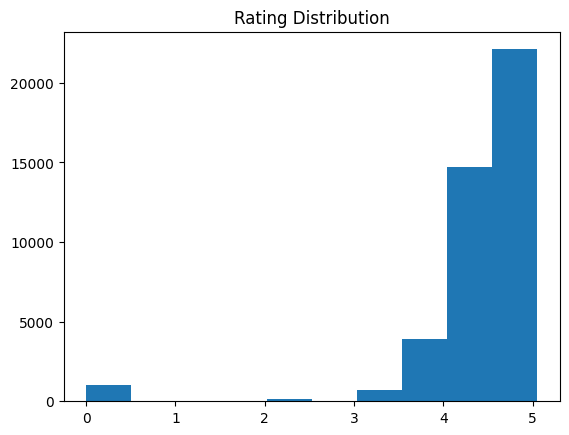

In [114]:
plt.hist(df['rating'])
plt.title("Rating Distribution")
plt.show()

## Best seller analysis

In [115]:
df['is_best_seller'].value_counts()

is_best_seller
0.0    42400
1.0      275
Name: count, dtype: int64

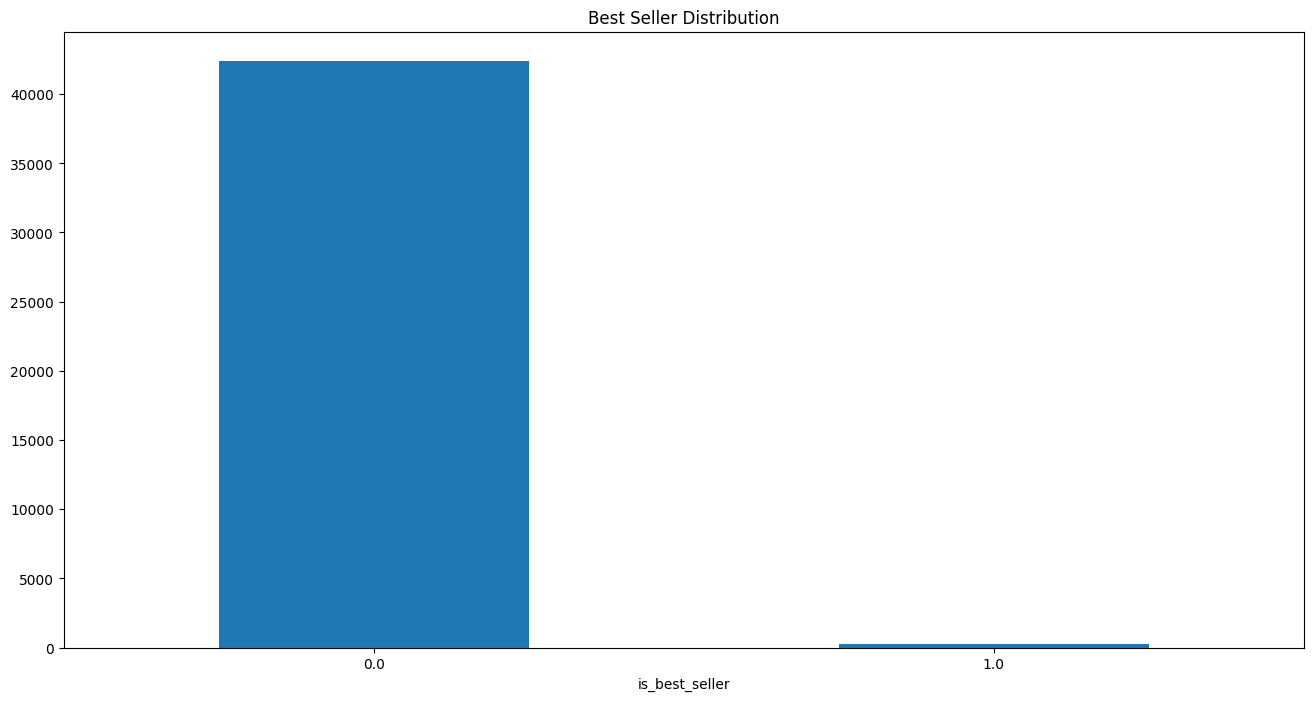

In [116]:
plt.figure(figsize=(16,8))
df['is_best_seller'].value_counts().plot(kind='bar')
plt.title("Best Seller Distribution")
plt.xticks(rotation=0)
plt.show()

## Sponsored products

In [117]:
df['is_sponsored'].value_counts()

is_sponsored
0    35664
1     7011
Name: count, dtype: int64

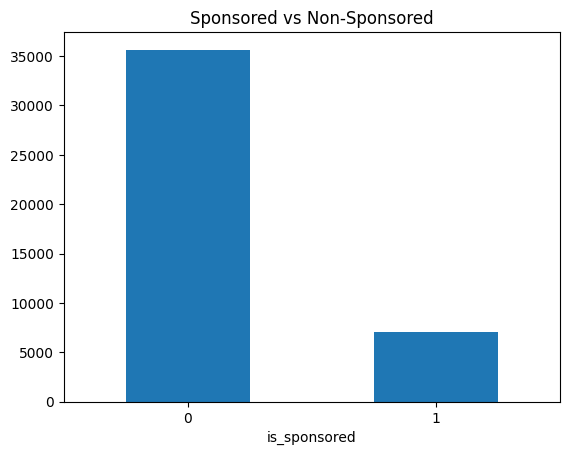

In [118]:
plt.figure()
df['is_sponsored'].value_counts().plot(kind='bar')
plt.title("Sponsored vs Non-Sponsored")
plt.xticks(rotation=0)
plt.show()

## correlation analysis

In [119]:
corr = df[['rating', 'number_of_reviews', 'listed_price']].corr()
print(corr)

                     rating  number_of_reviews  listed_price
rating             1.000000           0.080782      0.030714
number_of_reviews  0.080782           1.000000     -0.036031
listed_price       0.030714          -0.036031      1.000000


## plotting corr() using heatmap

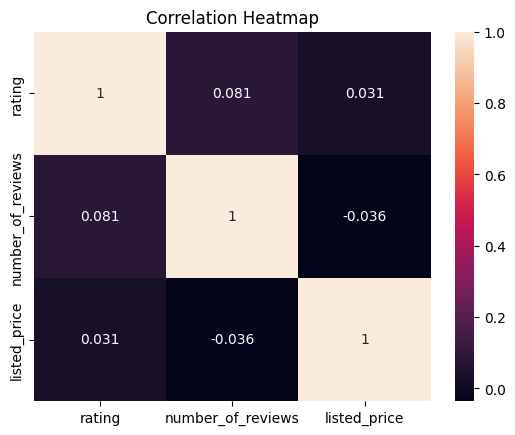

In [120]:

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

## Top 10 products based on reviews

In [121]:
df.sort_values(by='number_of_reviews', ascending=False).head(10)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,image_url,product_url,collected_at,score
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.75,865598.0,100K+ bought in past month,14.99,basic variant price: nan,0.00,1.0,0,No Coupon,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/81iJ+tnLAD...,/AmazonBasics-Performance-Alkaline-Batteries-C...,2025-08-21 11:14:29,64.938091
8565,SanDisk 32GB Ultra microSDHC UHS-I Memory Card...,4.75,645418.0,1K+ bought in past month,0,basic variant price: $8.25,0.00,0.0,0,No Coupon,0,0,https://m.media-amazon.com/images/I/71KcqXKf54...,/SanDisk-Ultra-microSDXC-Memory-Adapter/dp/B07...,2025-08-21 12:17:11,63.543861
8909,[Older Version] SanDisk 32GB 2-Pack Ultra Micr...,4.75,645416.0,400+ bought in past month,12.46,basic variant price: nan,15.99,0.0,0,No Coupon,Add to cart,"Delivery Tue, Sep 2",https://m.media-amazon.com/images/I/71QbhH9dKS...,/SanDisk-2-Pack-microSDHC-Memory-2x32GB/dp/B08...,2025-08-24 21:42:59,63.543847
17,Amazon Basics AAA Alkaline High-Performance Ba...,4.75,625776.0,100K+ bought in past month,14.49,basic variant price: nan,0.00,1.0,0,No Coupon,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/81Apg8B6+0...,/Amazon-Basics-AAA-High-Performance-36/dp/B00L...,2025-08-21 11:14:29,63.397059
695,"Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-S...",4.75,553927.0,10K+ bought in past month,5.99,basic variant price: nan,0.00,0.0,0,No Coupon,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/81AxKWgSaK...,/AmazonBasics-High-Speed-HDMI-Cable-1-Pack/dp/...,2025-08-21 11:20:11,62.817752
4486,"Amazon Fire TV Stick, sharp picture quality, f...",4.75,517617.0,500+ bought in past month,0,basic variant price: $39.99,0.00,0.0,0,No Coupon,0,0,https://m.media-amazon.com/images/I/51TjJOTfsl...,/fire-tv-stick-with-3rd-gen-alexa-voice-remote...,2025-08-21 11:47:47,62.495716
3100,SanDisk 1TB Extreme microSDXC UHS-I Memory Car...,4.85,353306.0,500+ bought in past month,89.35,basic variant price: $88.38,0.00,0.0,0,No Coupon,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/61yZgLITjm...,/SanDisk-Extreme-microSDXC-Memory-Adapter/dp/B...,2025-08-21 11:37:57,61.959199
4024,[Older Version] SanDisk 128GB Ultra microSDXC ...,4.75,315834.0,1K+ bought in past month,14.35,basic variant price: $13.82,0.00,0.0,0,No Coupon,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/61EF7HnrWq...,/SanDisk-128GB-MicroSDXC-Memory-Adapter/dp/B08...,2025-08-21 11:44:24,60.149132
750,Blink Mini - Compact indoor plug-in smart secu...,4.45,302790.0,6K+ bought in past month,0,basic variant price: $29.99,0.00,0.0,0,No Coupon,0,0,https://m.media-amazon.com/images/I/41UlY9ofud...,/Blink-Mini-Black-1Cam/dp/B09N6V1FHG/ref=sr_1_...,2025-08-21 11:20:48,56.162551
7868,SanDisk Cruzer Blade 8GB USB 2.0 Flash Drive- ...,4.65,298061.0,500+ bought in past month,7.77,basic variant price: $6.00,0.00,0.0,0,No Coupon,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/612jvLoXWZ...,/SanDisk-Cruzer-Blade-Drive-SDCZ50-008G-B35/dp...,2025-08-21 12:12:04,58.613514


## feature engineering using TfidfVectorizer

In [122]:
stemmer = SnowballStemmer('english')

def tokenize_stem(text):
    tokens = nltk.word_tokenize(str(text).lower())
    return [stemmer.stem(word) for word in tokens if word.isalnum()]

tfidf = TfidfVectorizer(
    tokenizer=tokenize_stem,
    token_pattern=None,
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['title'])

## ML part

## taking only required column to train a model

In [123]:
numerical_features = df[['rating', 'number_of_reviews', 'listed_price', 'score']]



## preparing data

In [124]:

X = hstack([tfidf_matrix, numerical_features])
y = df['is_sponsored']

## splitting the data into training and testing part

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## creating a dictionary of models with model name

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

## using for loop training the model and evalvating models

In [127]:
for name, model in models.items():
    print(f"\n {name}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.9769185705916813
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      7095
           1       0.98      0.89      0.93      1440

    accuracy                           0.98      8535
   macro avg       0.98      0.94      0.96      8535
weighted avg       0.98      0.98      0.98      8535


 Decision Tree
Accuracy: 0.9902753368482718
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      7095
           1       0.96      0.98      0.97      1440

    accuracy                           0.99      8535
   macro avg       0.98      0.99      0.98      8535
weighted avg       0.99      0.99      0.99      8535


 SVM
Accuracy: 0.9557117750439368
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      7095
           1       0.98      0.75 

#### NOTE : The models show high accuracy because precision and recall are also high, meaning the model is correctly predicting both classes with very few errors. The selected features have strong patterns that clearly distinguish sponsored and organic products, making this an easy classification problem.

## NLP  for recommendation (Extra)

## creationg recommend_product function

In [128]:
def recommend_products(query, top_n=10, min_rating=0):
    query = query.lower()

    # Find matching product
    matches = df[df['title'].str.lower().str.contains(query)]

    if matches.empty:
        return " No matching product found"

    idx = matches.index[0]

    # Compute similarity ONLY for query (FAST)
    sim_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Add similarity to dataframe
    df['similarity'] = sim_scores

    # Filter + rank
    results = df[df['rating'] >= min_rating]

    results = results.sort_values(
        by=['similarity', 'score'],
        ascending=False
    )

    results = results.iloc[1:top_n+1]

    return results[['title', 'rating', 'number_of_reviews']]

In [129]:
def search_products(query, top_n=10):
    query_vec = tfidf.transform([query])

    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    df['similarity'] = sim_scores

    results = df.sort_values(
        by=['similarity', 'score'],
        ascending=False
    ).head(top_n)

    return results[['title', 'rating', 'number_of_reviews']]

In [130]:
print("\n SEARCH RESULTS:")
search_products("iphone")



 SEARCH RESULTS:


,title,rating,number_of_reviews
10510,Belkin iPhone MagSafe Camera Mount for MacBook...,4.65,1754.0
5956,Belkin MagSafe 3-in-1 Wireless Charging Pad - ...,4.25,1357.0
5065,LISEN iPhone 16/15 Car Charger USB C Fast Char...,4.65,614.0
4913,SanDisk 256GB Phone Drive for iPhone - Works w...,4.05,206.0
8222,"OtterBox iPhone SE 3rd & 2nd Gen, iPhone 8 & i...",4.65,6790.0
6509,LISEN for MagSafe Car Mount Charger for iPhone...,4.55,1267.0
804,OtterBox iPhone SE 3rd & 2nd Gen (NOT SE4 – 20...,4.65,33125.0
8648,Speck Clear iPhone 16 Pro Case - Slim Phone Ca...,4.35,65.0
8417,Speck Clear iPhone 16 Pro Case - Slim Phone Ca...,4.35,64.0
1856,ESR 3 Pack for iPhone 16e/ iPhone 14/ iPhone 1...,4.45,30703.0


In [131]:
recommend_products("iphone", top_n=10, min_rating=3)

,title,rating,number_of_reviews
5396,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.65,375.0
5593,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.65,375.0
3928,NEEWER CM28 Wireless Lavalier Microphone Syste...,4.65,1274.0
5425,BOYALINK 2 Wireless Lavalier Microphone for iP...,4.55,64.0
8646,BOYA BY-V20 Wireless Microphones for iPhone 15...,4.65,419.0
2552,BOYA BY-V4U Wireless Lavalier Microphone for i...,4.35,245.0
7761,BOYA BY-V4U Wireless Lavalier Microphone for i...,4.35,245.0
1463,BOYA mini Wireless Lavalier Microphone for And...,4.35,831.0
25839,GODOX Cube-C Comb Kit 2 Wireless Microphone fo...,4.45,62.0
25872,GODOX Cube-C Comb Kit 2 Wireless Microphone fo...,4.45,62.0
